In [18]:
import os, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import re # Added import for regular expressions

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, f1_score)
from sklearn.preprocessing import label_binarize

tf.random.set_seed(42)
np.random.seed(42)

CLASSES  = ['dent', 'normal', 'scratch', 'stain']
IMG_SIZE = 64          # resized from original 96×96 for efficient training
DATA_DIR = 'images'    # root folder with one subfolder per class

os.makedirs('results', exist_ok=True)
os.makedirs('sample_predictions', exist_ok=True)

print(f"TensorFlow : {tf.__version__}")
print(f"Classes    : {CLASSES}")
print(f"Image size : {IMG_SIZE}×{IMG_SIZE} RGB")

TensorFlow : 2.20.0
Classes    : ['dent', 'normal', 'scratch', 'stain']
Image size : 64×64 RGB


In [2]:
#Task 2
#Load Dataset
X_all, y_all = [], []
for idx, cls in enumerate(CLASSES):
    folder = os.path.join(DATA_DIR, cls)
    files  = sorted([f for f in os.listdir(folder) if f.lower().endswith('.png')])
    for fname in files:
        img = Image.open(os.path.join(folder, fname)).convert('RGB')
        X_all.append(np.array(img, dtype=np.float32) / 255.0)
        y_all.append(idx)

X_all = np.array(X_all)
y_all = np.array(y_all)

print(f"{'─'*45}")
print(f"  Total images   : {len(X_all)}")
print(f"  Image shape    : {X_all.shape[1:]}  (H × W × C)")
print(f"  Pixel range    : [{X_all.min():.2f}, {X_all.max():.2f}]")
print(f"  Colour mode    : RGB (3 channels)")
print(f"{'─'*45}")
print(f"  Class distribution:")
for i, cls in enumerate(CLASSES):
    n = int((y_all == i).sum())
    print(f"    {cls:>8} : {n} images  ({n/len(y_all)*100:.1f}%)")
print(f"\n  Dataset is PERFECTLY BALANCED — 120 images per class ✅")

─────────────────────────────────────────────
  Total images   : 480
  Image shape    : (96, 96, 3)  (H × W × C)
  Pixel range    : [0.18, 1.00]
  Colour mode    : RGB (3 channels)
─────────────────────────────────────────────
  Class distribution:
        dent : 120 images  (25.0%)
      normal : 120 images  (25.0%)
     scratch : 120 images  (25.0%)
       stain : 120 images  (25.0%)

  Dataset is PERFECTLY BALANCED — 120 images per class ✅


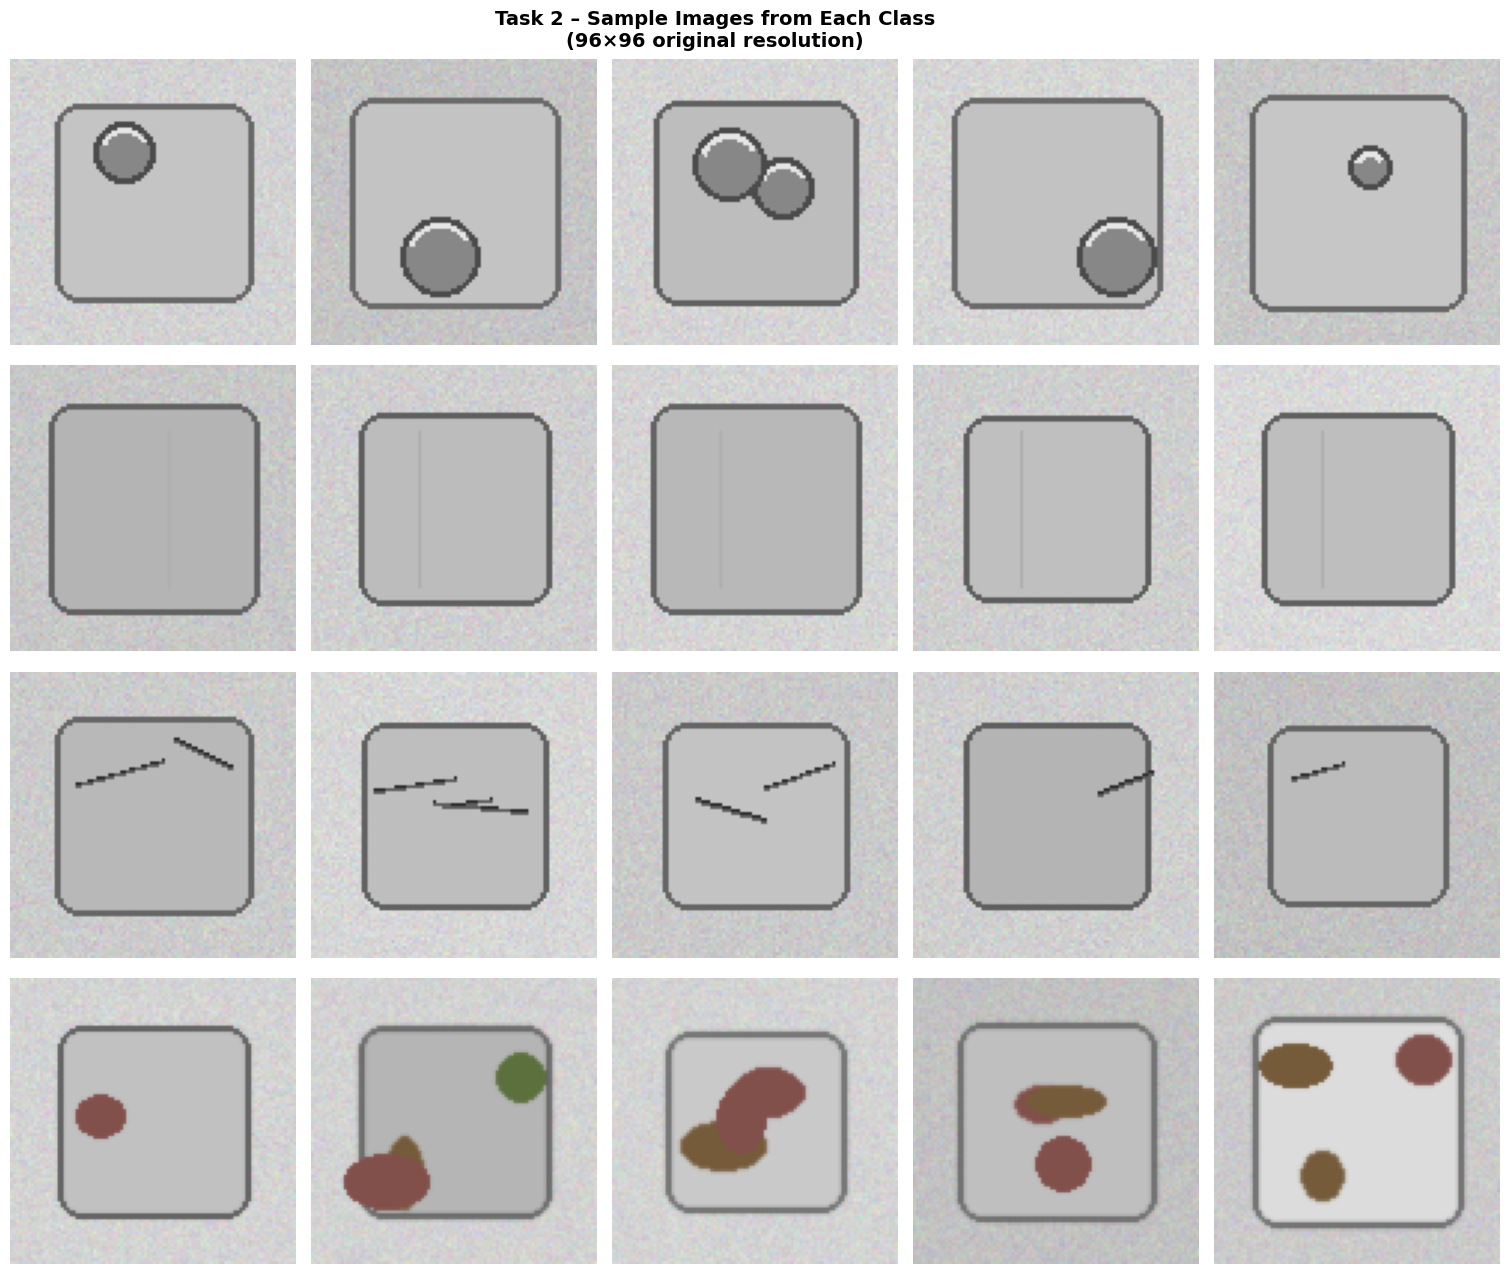


📋 Dataset Summary
  • Number of classes      : 4
  • Images per class       : 120
  • Total images           : 480
  • Original image size    : 96×96 pixels, RGB
  • Class imbalance        : None — perfectly balanced dataset
  • File format            : PNG


In [3]:
#Smaple Grid
ACCENT = ['#1F6FEB','#3FB950','#FF7B72','#D2A8FF']
fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.suptitle('Task 2 – Sample Images from Each Class\n(96×96 original resolution)',
             fontsize=14, fontweight='bold')
for row, cls in enumerate(CLASSES):
    idxs = np.where(y_all == row)[0][:5]
    for col, idx in enumerate(idxs):
        ax = axes[row, col]
        ax.imshow(X_all[idx])
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(cls.upper(), fontsize=13, fontweight='bold',
                          color=ACCENT[row], rotation=90, labelpad=10)
            ax.yaxis.set_label_position('left')
            ax.tick_params(left=False, labelleft=False)
plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.savefig('results/sample_grid.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📋 Dataset Summary")
print(f"  • Number of classes      : 4")
print(f"  • Images per class       : 120")
print(f"  • Total images           : 480")
print(f"  • Original image size    : 96×96 pixels, RGB")
print(f"  • Class imbalance        : None — perfectly balanced dataset")
print(f"  • File format            : PNG")

In [4]:
#Task 3
#Step 1 - Resize to 64x64
X = np.array([
    np.array(Image.fromarray((img*255).astype('uint8')).resize((IMG_SIZE, IMG_SIZE)),
             dtype=np.float32) / 255.0
    for img in X_all
])
y = y_all.copy()
print(f"Step 1 – Resized  : {X_all.shape[1:3]} → {X.shape[1:3]}")

# Step 2 – Pixel values already in [0,1] (divided by 255)
print(f"Step 2 – Normalised: pixel range [{X.min():.3f}, {X.max():.3f}]  (÷255)")

# Step 3 – Train (70%) / Validation (15%) / Test (15%) split
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.176, stratify=y_tv, random_state=42)

print(f"\nStep 3 – Split:")
print(f"  Training   : {X_train.shape[0]} images  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Validation : {X_val.shape[0]} images  ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"  Test       : {X_test.shape[0]} images  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"  Stratified : ✅ — class ratios preserved in all splits")

# Step 4 – Augmentation (applied inside model during training only)
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
], name="augmentation")
print(f"\nStep 4 – Augmentation pipeline (training only):")
print(f"  • RandomFlip  : horizontal mirroring")
print(f"  • RandomRotation : ±10° rotation")
print(f"  • Applied inside the model — inactive at inference time")


Step 1 – Resized  : (96, 96) → (64, 64)
Step 2 – Normalised: pixel range [0.125, 0.992]  (÷255)

Step 3 – Split:
  Training   : 336 images  (70%)
  Validation : 72 images  (15%)
  Test       : 72 images  (15%)
  Stratified : ✅ — class ratios preserved in all splits

Step 4 – Augmentation pipeline (training only):
  • RandomFlip  : horizontal mirroring
  • RandomRotation : ±10° rotation
  • Applied inside the model — inactive at inference time


In [5]:
#Task 4
def build_cnn(filters=(32, 64, 128), dense_units=256,
              dropout=0.5, lr=0.001, use_bn=True, name="SurfaceDefect_CNN"):
    """
    Build a configurable feed-forward CNN.

    Parameters
    ----------
    filters     : tuple[int]  – filters per convolutional block
    dense_units : int         – neurons in the fully-connected head
    dropout     : float       – Dropout rate after Dense layer
    lr          : float       – Adam learning rate
    use_bn      : bool        – whether to apply Batch Normalisation
    """
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input")
    x   = augmentation(inp)

    for i, f in enumerate(filters, start=1):
        #Convolution layer
        x = layers.Conv2D(f, (3, 3), padding='same',
                          kernel_initializer='he_normal',
                          name=f'conv_{i}')(x)
        if use_bn:
            x = layers.BatchNormalization(name=f'bn_{i}')(x)
        #Activation function (ReLU)
        x = layers.Activation('relu', name=f'relu_{i}')(x)
        #Pooling layer
        x = layers.MaxPooling2D((2, 2), name=f'pool_{i}')(x)

    #Flatten layer
    x = layers.Flatten(name='flatten')(x)
    #Dense (fully-connected) layer
    x = layers.Dense(dense_units, activation='relu',
                     kernel_initializer='he_normal', name='dense_1')(x)
    x = layers.Dropout(dropout, name='dropout')(x)
    #Output layer
    out = layers.Dense(len(CLASSES), activation='softmax', name='output')(x)

    model = keras.Model(inp, out, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

#Instantiate baseline
baseline = build_cnn(filters=(32, 64, 128), dense_units=256, dropout=0.5, lr=0.001)
baseline.summary()


Model: "SurfaceDefect_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,192,580 (8.36 MB)

 Trainable params: 2,192,132 (8.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
#Task 5
def evaluate_model(model, X_test, y_test):
    y_prob = model.predict(X_test, verbose=0)
    y_pred = y_prob.argmax(axis=1)
    acc    = float((y_pred == y_test).mean())
    f1     = f1_score(y_test, y_pred, average='macro', zero_division=0)
    y_bin  = label_binarize(y_test, classes=list(range(len(CLASSES))))
    auc    = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')
    cm     = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred,
                                   target_names=CLASSES, zero_division=0)
    return y_prob, y_pred, acc, f1, auc, cm, report

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
                                   restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=4, min_lr=1e-6)
]


In [9]:
#Train baseline
print("Training baseline CNN …")
history_baseline = baseline.fit(
    X_train, y_train,
    epochs=30, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks, verbose=1
)

Training baseline CNN …
Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 549ms/step - accuracy: 0.3333 - loss: 10.1926 - val_accuracy: 0.2500 - val_loss: 1.8209 - learning_rate: 0.0010
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 407ms/step - accuracy: 0.4702 - loss: 1.9738 - val_accuracy: 0.2500 - val_loss: 1.6824 - learning_rate: 0.0010
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 520ms/step - accuracy: 0.5923 - loss: 0.8829 - val_accuracy: 0.2500 - val_loss: 1.7346 - learning_rate: 0.0010
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 416ms/step - accuracy: 0.6369 - loss: 0.7506 - val_accuracy: 0.2500 - val_loss: 2.0563 - learning_rate: 0.0010
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 398ms/step - accuracy: 0.6786 - loss: 0.6762 - val_accuracy: 0.2500 - val_loss: 2.3141 - learning_rate: 0.0010
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 567ms/step - accuracy: 0.6488 - loss: 0.6820 - val_accuracy: 0.2500 - val_loss: 2.2788 - learning_rate: 0.0010
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 415ms/step - accuracy

In [10]:
#Evaluate baseline
yp, ypred, acc, f1, auc, cm, report = evaluate_model(baseline, X_test, y_test)

print(f"{'─'*50}")
print(f"  Training   Accuracy : {history_baseline.history['accuracy'][-1]:.4f}")
print(f"  Validation Accuracy : {history_baseline.history['val_accuracy'][-1]:.4f}")
print(f"  Training   Loss     : {history_baseline.history['loss'][-1]:.4f}")
print(f"  Validation Loss     : {history_baseline.history['val_loss'][-1]:.4f}")
print(f"{'─'*50}")
print(f"  Test Accuracy       : {acc:.4f}  ({acc:.1%})")
print(f"  Macro F1-Score      : {f1:.4f}")
print(f"  ROC-AUC (OvR macro) : {auc:.4f}")
print(f"\nClassification Report:\n{report}")


──────────────────────────────────────────────────
  Training   Accuracy : 0.9107
  Validation Accuracy : 0.9444
  Training   Loss     : 0.2691
  Validation Loss     : 0.2206
──────────────────────────────────────────────────
  Test Accuracy       : 0.9167  (91.7%)
  Macro F1-Score      : 0.9142
  ROC-AUC (OvR macro) : 0.9974

Classification Report:
              precision    recall  f1-score   support

        dent       0.94      0.94      0.94        18
      normal       0.82      1.00      0.90        18
     scratch       0.93      0.72      0.81        18
       stain       1.00      1.00      1.00        18

    accuracy                           0.92        72
   macro avg       0.92      0.92      0.91        72
weighted avg       0.92      0.92      0.91        72



In [22]:
#Hyperparameter experiments
experiments = [
    {
        "name":    "Exp1 – Deeper CNN (4 blocks)",
        "desc":    "Adds a 4th conv block (256 filters). Tests if depth helps.",
        "filters": (32, 64, 128, 256), "dense": 256,
        "dropout": 0.5, "lr": 0.001, "bs": 32, "use_bn": True
    },
    {
        "name":    "Exp2 – No Batch Normalisation",
        "desc":    "Removes BatchNorm. Shows its effect on training stability.",
        "filters": (32, 64, 128), "dense": 256,
        "dropout": 0.5, "lr": 0.001, "bs": 32, "use_bn": False
    },
    {
        "name":    "Exp3 – High LR + Large Batch",
        "desc":    "lr=0.01, batch=64. Tests instability from too-large steps.",
        "filters": (32, 64, 128), "dense": 256,
        "dropout": 0.3, "lr": 0.01, "bs": 64, "use_bn": True
    },
]

# Sanitize the 'name' field within each experiment dictionary immediately
for exp_dict in experiments:
    exp_dict['original_name'] = exp_dict['name'] # Keep original for desc/logging
    exp_dict['name'] = re.sub(r'[^a-zA-Z0-9_]', '_', exp_dict['name'])

all_results  = [{'name': 'Baseline', 'desc': '[32,64,128]+BN lr=0.001 bs=32',
                 'history': history_baseline.history,
                 'acc': acc, 'f1': f1, 'auc': auc, 'cm': cm}]
all_histories = {'Baseline': history_baseline.history}

for exp in experiments:
    print(f"\nTraining: {exp['original_name']}  — {exp['desc']}") # Use original for printing
    tf.keras.backend.clear_session() # Clear the Keras session for each new model
    # No need for a separate sanitized_name variable here, exp['name'] is already sanitized
    m = build_cnn(filters=exp['filters'], dense_units=exp['dense'],
                  dropout=exp['dropout'], lr=exp['lr'],
                  use_bn=exp['use_bn'], name=exp['name']) # Pass the already sanitized exp['name']
    h = m.fit(X_train, y_train,
              epochs=30, batch_size=exp['bs'],
              validation_data=(X_val, y_val),
              callbacks=callbacks, verbose=0)
    yp_e, ypred_e, acc_e, f1_e, auc_e, cm_e, rpt_e = evaluate_model(m, X_test, y_test)
    all_results.append({'name': exp['original_name'], 'desc': exp['desc'], # Use original for results list
                        'history': h.history,
                        'acc': acc_e, 'f1': f1_e, 'auc': auc_e, 'cm': cm_e})
    all_histories[exp['original_name']] = h.history # Use original for history dict
    print(f"  → Acc={acc_e:.4f}  F1={f1_e:.4f}  AUC={auc_e:.4f}")


Training: Exp1 – Deeper CNN (4 blocks)  — Adds a 4th conv block (256 filters). Tests if depth helps.
  → Acc=0.2500  F1=0.1000  AUC=0.6155

Training: Exp2 – No Batch Normalisation  — Removes BatchNorm. Shows its effect on training stability.


  → Acc=0.2500  F1=0.1000  AUC=0.6641

Training: Exp3 – High LR + Large Batch  — lr=0.01, batch=64. Tests instability from too-large steps.
  → Acc=0.2500  F1=0.1000  AUC=0.5000


In [23]:
#Comparable table
import pandas as pd

table = pd.DataFrame([{
    'Model':      r['name'],
    'Description':r['desc'],
    'Train Acc':  round(r['history']['accuracy'][-1], 4),
    'Val Acc':    round(r['history']['val_accuracy'][-1], 4),
    'Test Acc':   round(r['acc'], 4),
    'Macro F1':   round(r['f1'], 4),
    'ROC-AUC':    round(r['auc'], 4),
} for r in all_results])

print(table.to_string(index=False))

                        Model                                                Description  Train Acc  Val Acc  Test Acc  Macro F1  ROC-AUC
                     Baseline                              [32,64,128]+BN lr=0.001 bs=32     0.9107   0.9444    0.9167    0.9142   0.9974
 Exp1 – Deeper CNN (4 blocks) Adds a 4th conv block (256 filters). Tests if depth helps.     0.9018   0.2500    0.2500    0.1000   0.6155
Exp2 – No Batch Normalisation Removes BatchNorm. Shows its effect on training stability.     0.5208   0.6250    0.2500    0.1000   0.6641
 Exp3 – High LR + Large Batch lr=0.01, batch=64. Tests instability from too-large steps.     0.2500   0.2500    0.2500    0.1000   0.5000


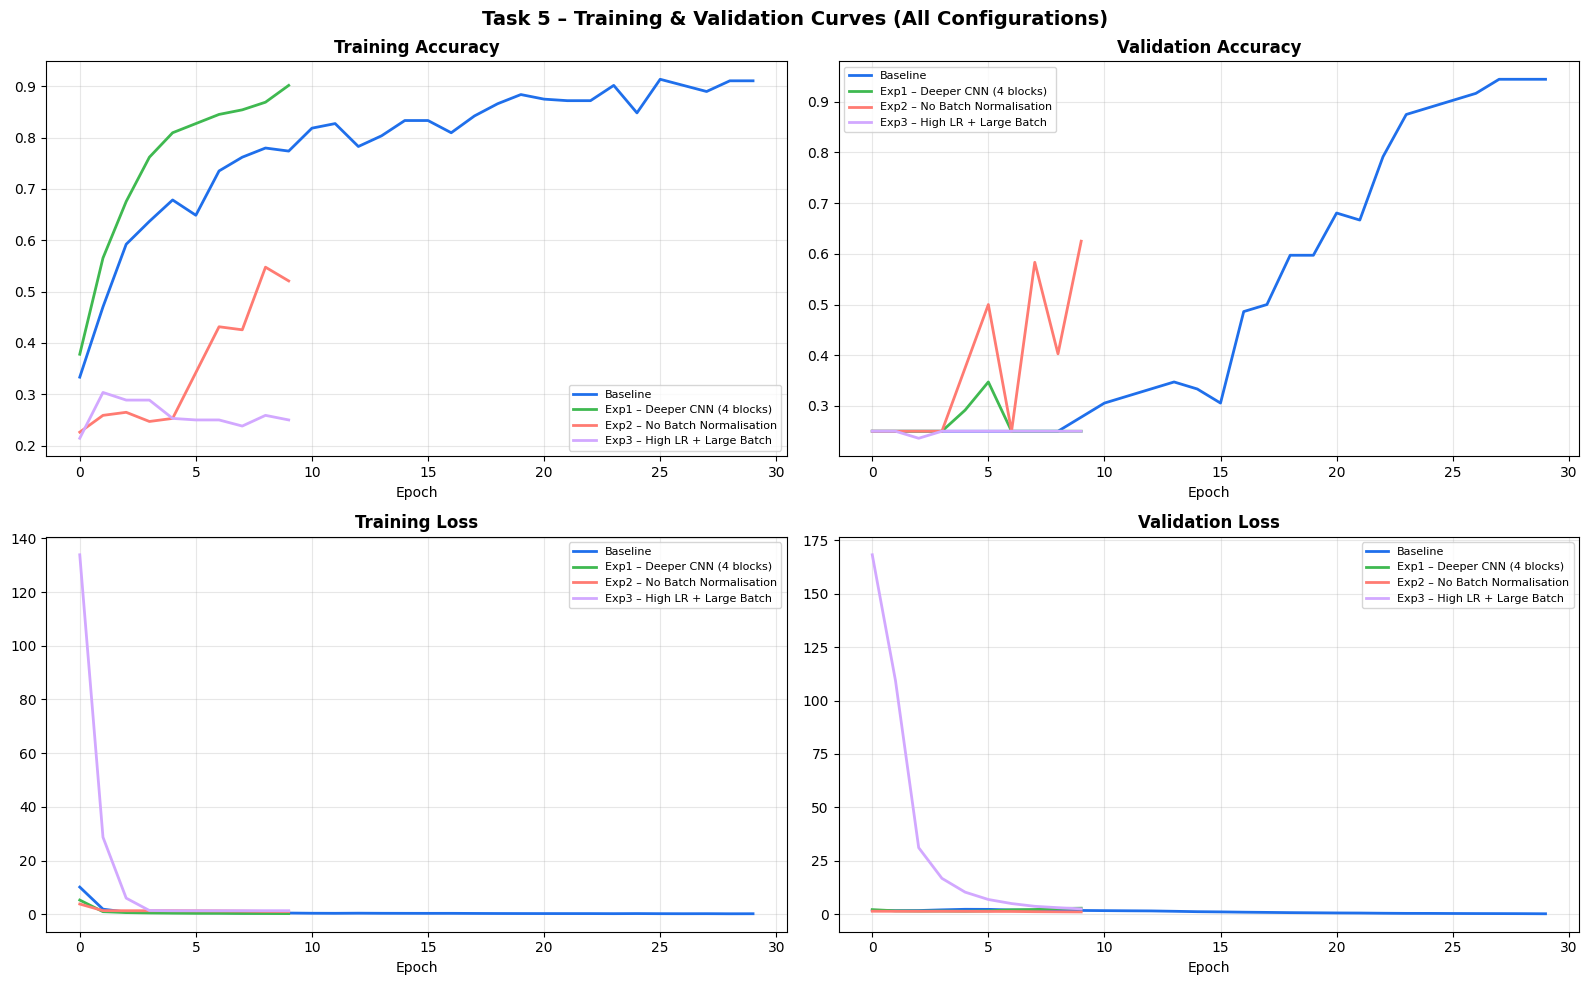

In [24]:
#plot accuracy/loss curves
COLORS = ['#1F6FEB','#3FB950','#FF7B72','#D2A8FF']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Task 5 – Training & Validation Curves (All Configurations)',
             fontsize=14, fontweight='bold')

for ax, metric, title in zip(axes.flatten(),
        ['accuracy','val_accuracy','loss','val_loss'],
        ['Training Accuracy','Validation Accuracy',
         'Training Loss','Validation Loss']):
    for (lbl, hist), color in zip(all_histories.items(), COLORS):
        ax.plot(hist[metric], color=color, lw=2, label=lbl)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/accuracy_loss_curves.png', dpi=140, bbox_inches='tight')
plt.show()

Best model: Baseline  Acc=91.7%


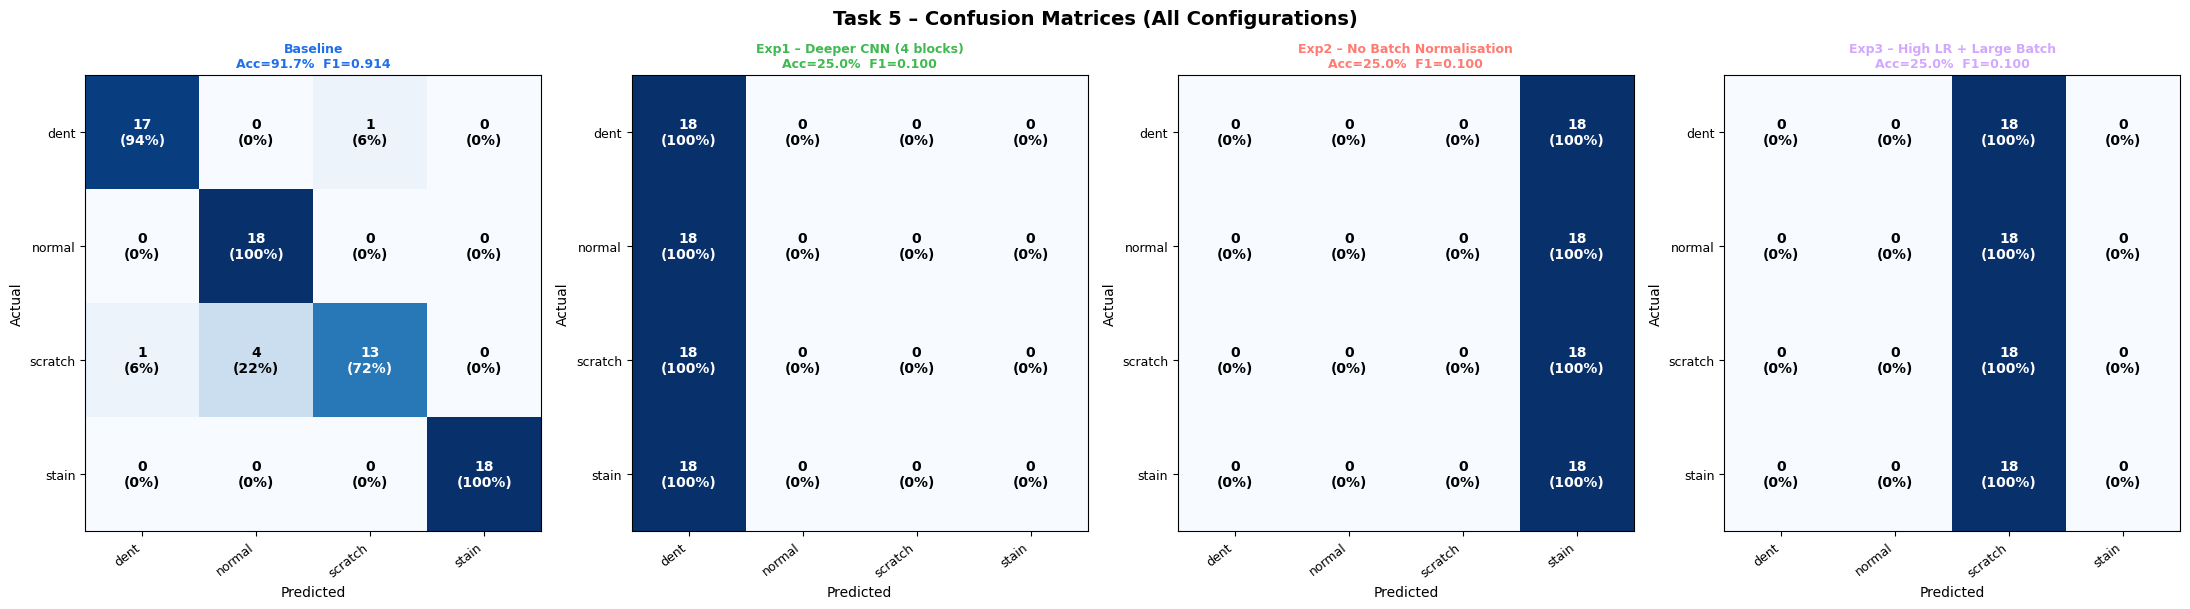

In [26]:
#Confusion matrix for best model
best = max(all_results, key=lambda r: r['acc'])
print(f"Best model: {best['name']}  Acc={best['acc']:.1%}")
cm_best = best['cm']

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('Task 5 – Confusion Matrices (All Configurations)',
             fontsize=14, fontweight='bold')

for ax, r, color in zip(axes, all_results, COLORS):
    cm_i   = np.array(r['cm'])
    cm_n   = cm_i.astype(float) / (cm_i.sum(1, keepdims=True) + 1e-9)
    ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(CLASSES, rotation=38, ha='right', fontsize=9)
    ax.set_yticklabels(CLASSES, fontsize=9)
    for row in range(4):
        for col in range(4):
            ax.text(col, row, f"{cm_i[row,col]}\n({cm_n[row,col]:.0%})",
                    ha='center', va='center', fontsize=10, fontweight='bold',
                    color='white' if cm_n[row,col] > 0.55 else 'black')
    ax.set_title(f"{r['name']}\nAcc={r['acc']:.1%}  F1={r['f1']:.3f}",
                 fontweight='bold', color=color, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=140, bbox_inches='tight')
plt.show()

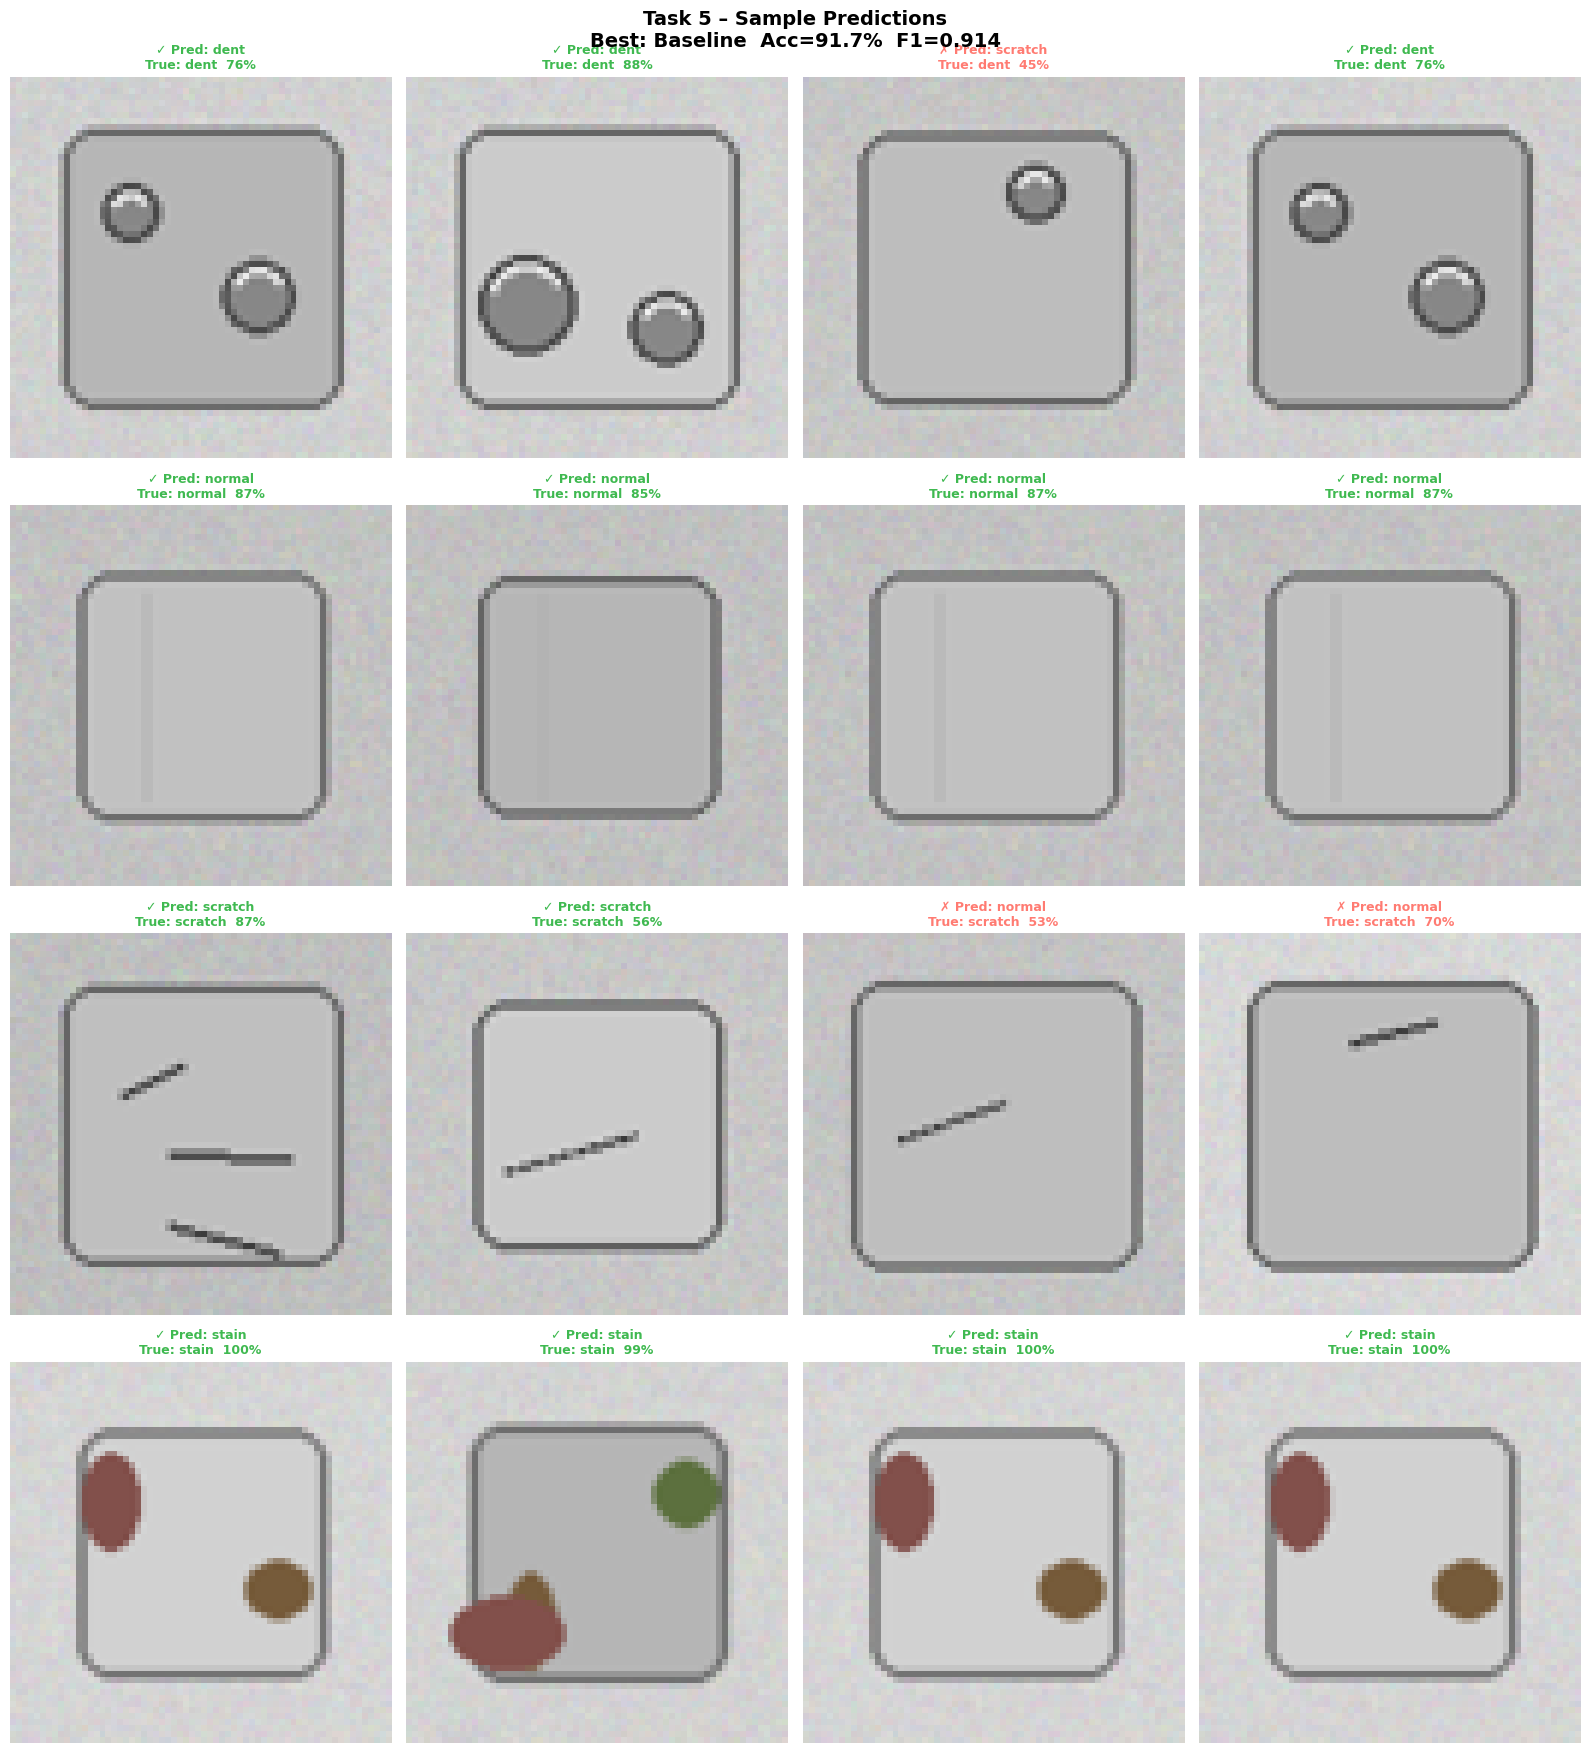

In [27]:
#Sample predictions (best model)
best_model_obj = max(
    [(m, r) for m, r in zip([baseline] + [None]*3, all_results)],
    key=lambda x: x[1]['acc']
)[0]
#For display, use stored results from the best model
best_res  = best
yp_best   = best_model_obj.predict(X_test, verbose=0) if best_model_obj else yp
ypred_best = yp_best.argmax(1)

fig, axes = plt.subplots(4, 4, figsize=(16, 18))
fig.suptitle(f"Task 5 – Sample Predictions\nBest: {best['name']}  "
             f"Acc={best['acc']:.1%}  F1={best['f1']:.3f}",
             fontsize=14, fontweight='bold')

for cls_idx, cls_name in enumerate(CLASSES):
    cls_idx_list = np.where(y_test == cls_idx)[0]
    correct_i    = [i for i in cls_idx_list if ypred_best[i] == cls_idx][:2]
    incorrect_i  = [i for i in cls_idx_list if ypred_best[i] != cls_idx][:2]
    sample_idxs  = (correct_i + incorrect_i)[:4]
    while len(sample_idxs) < 4:
        sample_idxs.append(cls_idx_list[0])

    for col, ti in enumerate(sample_idxs):
        ax = axes[cls_idx, col]
        ax.imshow(X_test[ti])
        ax.axis('off')
        pred_c  = int(ypred_best[ti])
        conf    = float(yp_best[ti][pred_c])
        true_c  = int(y_test[ti])
        correct = pred_c == true_c
        color   = '#3FB950' if correct else '#FF7B72'
        ax.set_title(f"{'✓' if correct else '✗'} Pred: {CLASSES[pred_c]}\n"
                     f"True: {CLASSES[true_c]}  {conf:.0%}",
                     fontsize=9, color=color, fontweight='bold')

for cls_i, (cls, col) in enumerate(zip(CLASSES, ['#1F6FEB','#3FB950','#FF7B72','#D2A8FF'])):
    axes[cls_i, 0].set_ylabel(cls.upper(), color=col, fontsize=12,
                               fontweight='bold', rotation=90)

plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png', dpi=140, bbox_inches='tight')
plt.show()
